<span style="float: left;padding: 1.3em">![logo](../logo.png)</span>

# Gravitational Wave Open Data Workshop

## Tutorial 3.1: Estimating the PSD with GWpy

This tutorial will present how to do some signal processing with GWpy.

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/Signal_Processing/Tuto_1_Estimating_PSD_with_GWpy.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).


In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Installation (execute only if running on a cloud platform, like Google Colab, or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [2]:
# -- Uncomment following line if running in Google Colab
#! pip install -q 'gwpy==3.0.14' 'cryptography==43.0.0'

## Initialization

In [3]:
# The first import of gwpy can take some time (especially on cloud platforms).
# This is mainly due to matplotlib taking some time to import (this is normal).
import gwpy
print(gwpy.__version__)

3.0.14


## Handling data in the frequency domain using the Fourier transform

The [Fourier transform](https://en.wikipedia.org/wiki/Fourier_transform) is a widely-used mathematical tool to expose the frequency-domain content of a time-domain signal, meaning we can see which frequencies contain lots of power, and which have less.

Let's reload the data used previously.

In [4]:
from gwosc.datasets import event_gps
from gwpy.timeseries import TimeSeries
gps = event_gps('GW190412')
segment = (int(gps)-5, int(gps)+5)
ldata = TimeSeries.fetch_open_data('L1', *segment, verbose=True)

Fetched 1 URLs from gwosc.org for [1239082257 .. 1239082267))
Reading data... [Done]


We can calculate the Fourier transform of our `TimeSeries` using the [fft()](https://gwpy.readthedocs.io/en/v3.0.13/api/gwpy.timeseries.TimeSeries/?highlight=fourier#gwpy.timeseries.TimeSeries.fft) method:

In [5]:
fft = ldata.fft()
print(fft)

FrequencySeries([-1.45894410e-21+0.00000000e+00j,
                 -2.91834926e-21-4.52905657e-23j,
                 -2.91973330e-21-9.06202944e-23j, ...,
                 -2.38723982e-23+4.67871178e-26j,
                 -2.38345362e-23+1.80394058e-26j,
                 -2.38457175e-23+0.00000000e+00j]
                unit: dimensionless,
                f0: 0.0 Hz,
                df: 0.1 Hz,
                epoch: 1239082257.0,
                name: Strain,
                channel: None)


The result is a [`FrequencySeries`](https://gwpy.readthedocs.io/en/v3.0.13/api/gwpy.frequencyseries.FrequencySeries/#gwpy.frequencyseries.FrequencySeries), with complex amplitude, representing the amplitude and phase of each frequency in our data.
We can use `abs()` to extract the amplitude and plot it:

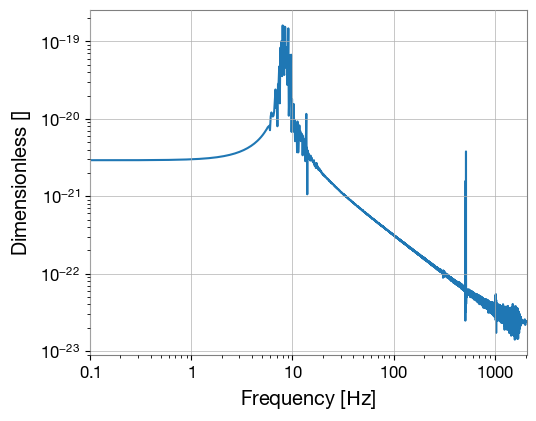

In [6]:
plot = fft.abs().plot(xscale="log", yscale="log")
plot.show(warn=False)

This doesn't look correct at all!
The problem is that the FFT works under the assumption that our data are periodic, which means that the edges of our data look like discontinuities when transformed.
We need to apply a window function to our time-domain data before transforming, which we can do using the [`scipy.signal`](https://docs.scipy.org/doc/scipy-1.13.1/reference/signal.html) module:

In [7]:
from scipy.signal import get_window
window = get_window('hann', ldata.size)
lwin = ldata * window

Let's try our transform again and see what we get

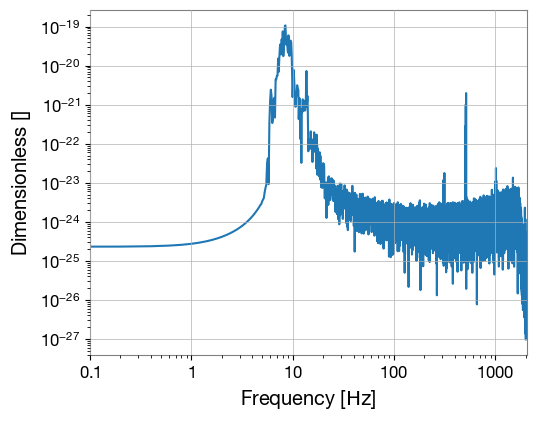

In [8]:
fftamp = lwin.fft().abs()
plot = fftamp.plot(xscale="log", yscale="log")
plot.show(warn=False)

This looks a little more like what we expect for the amplitude spectral density of a gravitational-wave detector.

## Estimating the power spectral density

The dense fluctuations in the above plot at frequencies larger than 10 Hz seem completely random. This is indeed the intrinsic noise in the estimate of the spectral content of the signal from a single FFT. We can reduce these fluctuations by averaging many estimates of the signal FFT. But, being the FFT components complex quantities, what we really want to average are their squared moduli. This quantity is named [Power Spectral Density (PSD)](https://en.wikipedia.org/wiki/Spectral_density),  and what we have just described is [Welch's estimation method](https://en.wikipedia.org/wiki/Welch%27s_method).
It is also convenient to express the result not as a power but as an amplitude, taking the square root of the above expression. The resulting quantity takes the name Amplitude Spectral Density (ASD) of the signal.

GWpy library provides the [`asd()`](https://gwpy.readthedocs.io/en/v3.0.13/api/gwpy.timeseries.TimeSeries/?highlight=asd#gwpy.timeseries.TimeSeries.asd) method of `TimeSeries`, which uses the above technique to combine FFTs estimated on overlapping, windowed chunks of data.

Alternatively, one could have combined the various FFT estimates calculating their median, which is a more robust statistic than the mean implemented in Welch's method with respect to spurious fluctuations of the signal level.

The `asd()` in GWpy accepts both `'median'` or `'welch'` as possible methods to estmate the ASD of a signal.

Explore the difference in the ASD estimate result by changing the values of the parameters `fftlength`, the duration in seconds of the data used to estimate each FFT, and the `method` used to average them. Take a look also at the [other optional parameters](https://gwpy.readthedocs.io/en/v3.0.13/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries.asd).

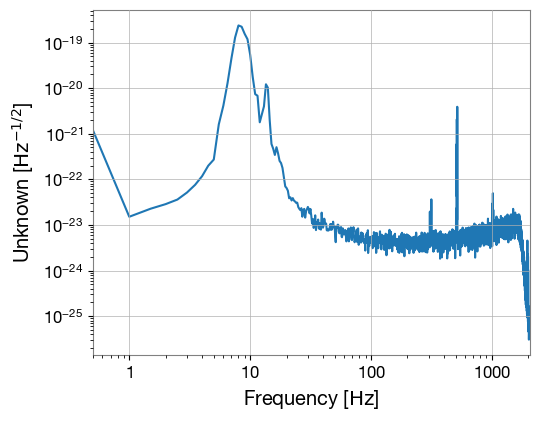

In [9]:
asd = ldata.asd(fftlength=2, method="median")
plot = asd.plot()
plot.show(warn=False)

Let's customize this figure by zooming in the frequency range of interest, that is, above the seismic noise shoulder at 10 Hz and below the cut-off at the Nyquist frequency, and resizing the y-axis accordingly.

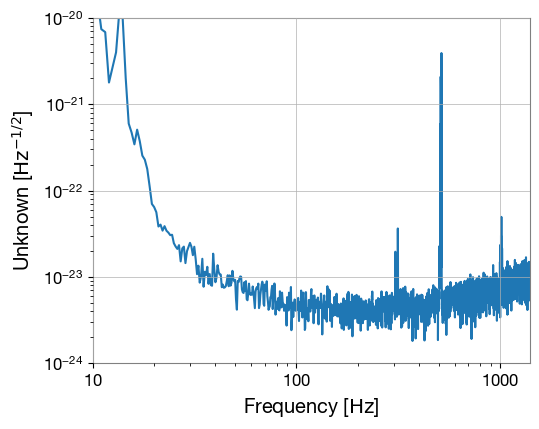

In [10]:
ax = plot.gca()
ax.set(xlim=(10, 1400), ylim=(1e-24, 1e-20))
plot

The ASD is a standard tool used to study the frequency-domain sensitivity of a gravitational-wave detector.
For the LIGO-Livingston data we loaded, we can see large spikes at certain frequencies, including

- ~300 Hz
- ~500 Hz
- ~1000 Hz

The [O3 spectral lines](https://gwosc.org/O3/o3aspeclines/) page on GWOSC describes a number of these spectral features for O3, with some of them being forced upon us, and some being deliberately introduced to help with interferometer control.

Loading more data allows for more FFTs to be averaged during the ASD estimation, meaning random variations get averaged out, and we can see more detail:

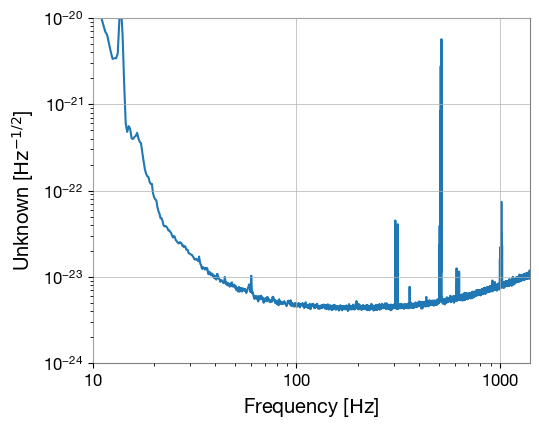

In [11]:
ldata2 = TimeSeries.fetch_open_data('L1', int(gps)-512, int(gps)+512, cache=True)
lasd2 = ldata2.asd(fftlength=4, method="median")
plot = lasd2.plot()
ax = plot.gca()
ax.set_xlim(10, 1400)
ax.set_ylim(1e-24, 1e-20)
plot.show(warn=False)

Now we can see some more features, including a small bump at about 60 Hz, the frequency of the electric mains in the US.

For comparison, we can load the LIGO-Hanford and Virgo data and plot them as well:

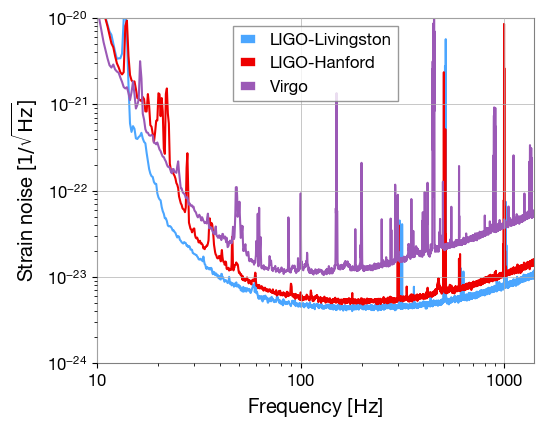

In [12]:
# get Hanford data
hdata2 = TimeSeries.fetch_open_data('H1', int(gps)-512, int(gps)+512, cache=True)
hasd2 = hdata2.asd(fftlength=4, method="median")

# get Virgo data
vdata2 = TimeSeries.fetch_open_data('V1', int(gps)-512, int(gps)+512, cache=True)
vasd2 = vdata2.asd(fftlength=4, method="median")

# and plot using standard colours
ax.plot(hasd2, label='LIGO-Hanford', color='gwpy:ligo-hanford')
ax.plot(vasd2, label='Virgo', color='gwpy:virgo')

# update the Livingston line to use standard colour, and have a label
lline = ax.lines[0]
lline.set_color('gwpy:ligo-livingston')  # change colour of Livingston data
lline.set_label('LIGO-Livingston')

ax.set_ylabel(r'Strain noise [$1/\sqrt{\mathrm{Hz}}$]')
ax.legend()
plot

Now we can see clearly the relative sensitivity of each detectors of LIGO and Virgo, the common features between those, like the general trend at low and high frequency, and those unique to each observatory.

# Challenges:

## Quiz Question 1 :

Make an ASD around the time of an O1 event, GW150914 for L1 detector.  Compare this with the ASDs around GW190412 for L1 detector.  Which data have lower noise - and so are more sensitive - around 100 Hz?
